In [1]:
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import seaborn as sns
import pickle as pkl
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from emle.models import EMLE
from emle.train import EMLETrainer
from emle.train._utils import pad_to_max

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
data = h5py.File("polarizabilities.h5", "r")
atomic_alphas = data["iso"][:]
atomic_alphas_ds = pad_to_max(atomic_alphas).to(device=device, dtype=dtype)

In [4]:
# Dataset 1
dataset = pkl.load(
    open(
        "/scratch1/joao/tip3p_final/bespoke_models/sampling_iter3/ds_sampler_iter3.pkl",
        "rb",
    )
)
xyz_ds = pad_to_max(dataset["xyz_qm"])
species_ds = pad_to_max(dataset["z"])
alphas_ds = pad_to_max(dataset["alpha"])
s_ds = pad_to_max(dataset["s"])

# Pad to max number of atoms
xyz_ds = xyz_ds.to(device=device, dtype=dtype)
species_ds = species_ds.to(device=device, dtype=torch.long)
s_ds = s_ds.to(device=device, dtype=dtype)
q_mol = torch.zeros(xyz_ds.shape[0]).to(device=device, dtype=dtype)

### Get EMLE atomic polarizabilities

In [5]:
# Get polarizabilities for patched model
emle = EMLE(
    model="../../emle_models/ligand_patched_reference_iter2.mat",
    alpha_mode="reference",
    device=device,
)
emle_base = emle._emle_base
s, q_core, q_val, A_thole, *_ = emle_base(species_ds, xyz_ds, q_mol)
alpha_emle_patched = emle_base.get_isotropic_polarizabilities(A_thole)
alpha_emle_patched = alpha_emle_patched.detach() * (species_ds > 0)

# Get polarizabilities for bespoke model
emle = EMLE(
    model="../../emle_models/ligand_bespoke_iter2.mat",
    alpha_mode="reference",
    device=device,
)
emle_base = emle._emle_base
s, q_core, q_val, A_thole, _, alpha_emle_bespoke_atomic = emle_base(
    species_ds, xyz_ds, q_mol
)
alpha_emle_bespoke = emle_base.get_isotropic_polarizabilities(A_thole)
alpha_emle_bespoke = alpha_emle_bespoke.detach() * (species_ds > 0)

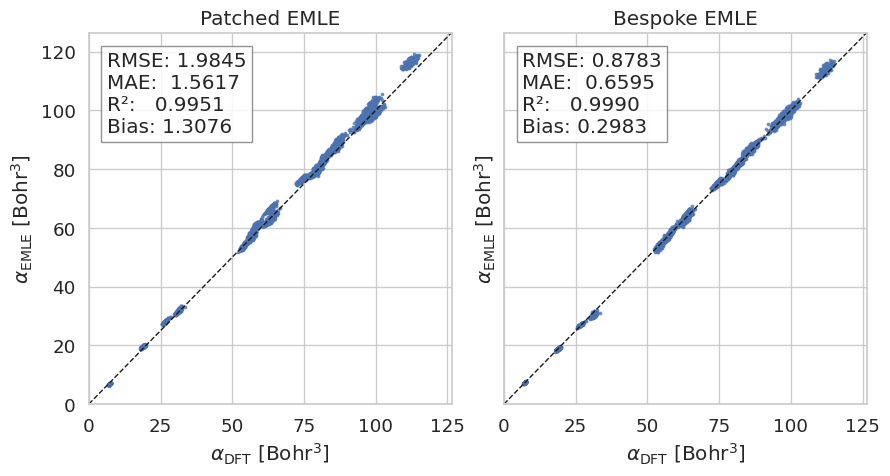

In [6]:
sns.set(style="whitegrid", font_scale=1.2)

alpha_dft = alphas_ds.diagonal(dim1=1, dim2=2).sum(-1).cpu().numpy() / 3.0
alpha_patched = alpha_emle_patched.sum(dim=1).cpu().numpy()
alpha_bespoke = alpha_emle_bespoke.sum(dim=1).cpu().numpy()

datasets = [
    ("Patched EMLE", alpha_patched),
    ("Bespoke EMLE", alpha_bespoke),
]

xlabel = r"$\alpha_{\mathrm{DFT}}$ [Bohr$^3$]"
ylabel = r"$\alpha_{\mathrm{EMLE}}$ [Bohr$^3$]"

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(9, 5))

for ax, (title, y_pred) in zip(axes, datasets):
    y_true = alpha_dft
    mask = y_true > 0

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
    mae = mean_absolute_error(y_true[mask], y_pred[mask])
    r2 = r2_score(y_true[mask], y_pred[mask])
    bias = np.mean(y_pred[mask] - y_true[mask])

    # Scatter
    ax.scatter(y_true, y_pred, alpha=0.7, s=3)

    lims = [0, y_true.max() * 1.1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Labels
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Metrics box
    text_metrics = (
        f"RMSE: {rmse:.4f}\nMAE:  {mae:.4f}\nR²:   {r2:.4f}\nBias: {bias:.4f}"
    )

    ax.text(
        0.05,
        0.95,
        text_metrics,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"),
    )

plt.tight_layout()
plt.show()

### Create training dataset

In [7]:
perm = torch.randperm(xyz_ds.shape[0])
n_samples = len(perm)
n_train = int(0.8 * n_samples)
train_idx = perm[:n_train]
val_idx = perm[n_train:]


def split_tensor(t, idx_train, idx_val):
    return t[idx_train], t[idx_val]


xyz_train, xyz_val = split_tensor(xyz_ds, train_idx, val_idx)
species_train, species_val = split_tensor(species_ds, train_idx, val_idx)
atomic_alpha_train, atomic_alpha_val = split_tensor(
    atomic_alphas_ds, train_idx, val_idx
)
mol_alpha_train, mol_alpha_val = split_tensor(alphas_ds, train_idx, val_idx)
s_train, s_val = split_tensor(s_ds, train_idx, val_idx)

### Train atomic polarizabilities

In [8]:
plot_data_filename = "atomic_alpha_training_data_results.mat"
trainer = EMLETrainer()
trainer.train(
    z=species_train,
    xyz=xyz_train,
    s=s_train,
    alpha=mol_alpha_train,
    alpha_atomic=atomic_alpha_train,
    q_mol=torch.zeros(xyz_train.shape[0]),
    lr_thole=1e-1,
    epochs=250,
    emle_model="../../emle_models/ligand_patched_reference_iter2.mat",
    plot_data_filename=plot_data_filename,
    model_filename="ligand_patched_reference_iter2_atomic_alpha.mat",
    l2_reg_thole=0.0,
    weight_alpha_atomic=1.0,
    weight_alpha_mol=0.1,
)

2025-11-29 16:30:29.058 | INFO     | emle.train._trainer:train:625 - Loading pre-trained EMLE model from '../../emle_models/ligand_patched_reference_iter2.mat'
2025-11-29 16:30:29.090 | INFO     | emle.train._trainer:train:654 - Fitting a_Thole and k_Z values...


ValueError: too many values to unpack (expected 5)

### Plot results

In [ ]:
# Get training results
training_results = scipy.io.loadmat(plot_data_filename)

# Get testing results
emle = EMLE(
    model="ligand_patched_reference_iter2_atomic_alpha.mat",
    device=device,
    alpha_mode="reference",
)
emle_base = emle._emle_base
_, _, _, A_thole, _ = emle_base.forward(
    species_val,
    xyz_val.to(torch.float32),
    torch.zeros(xyz_val.shape[0], device=device),
    calc_c6=False,
)
alpha_emle_val = emle_base.get_isotropic_polarizabilities(A_thole)
alpha_emle_val = alpha_emle_val.detach() * (species_val > 0)

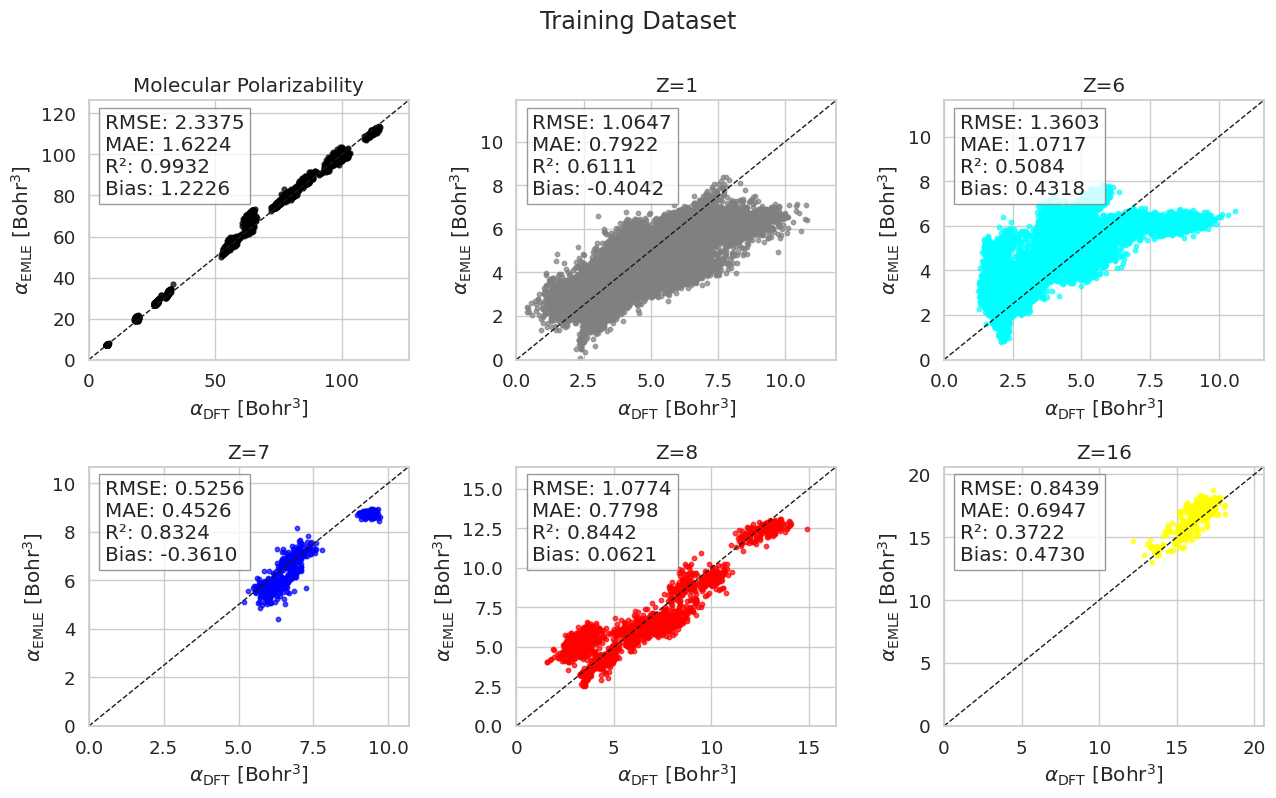

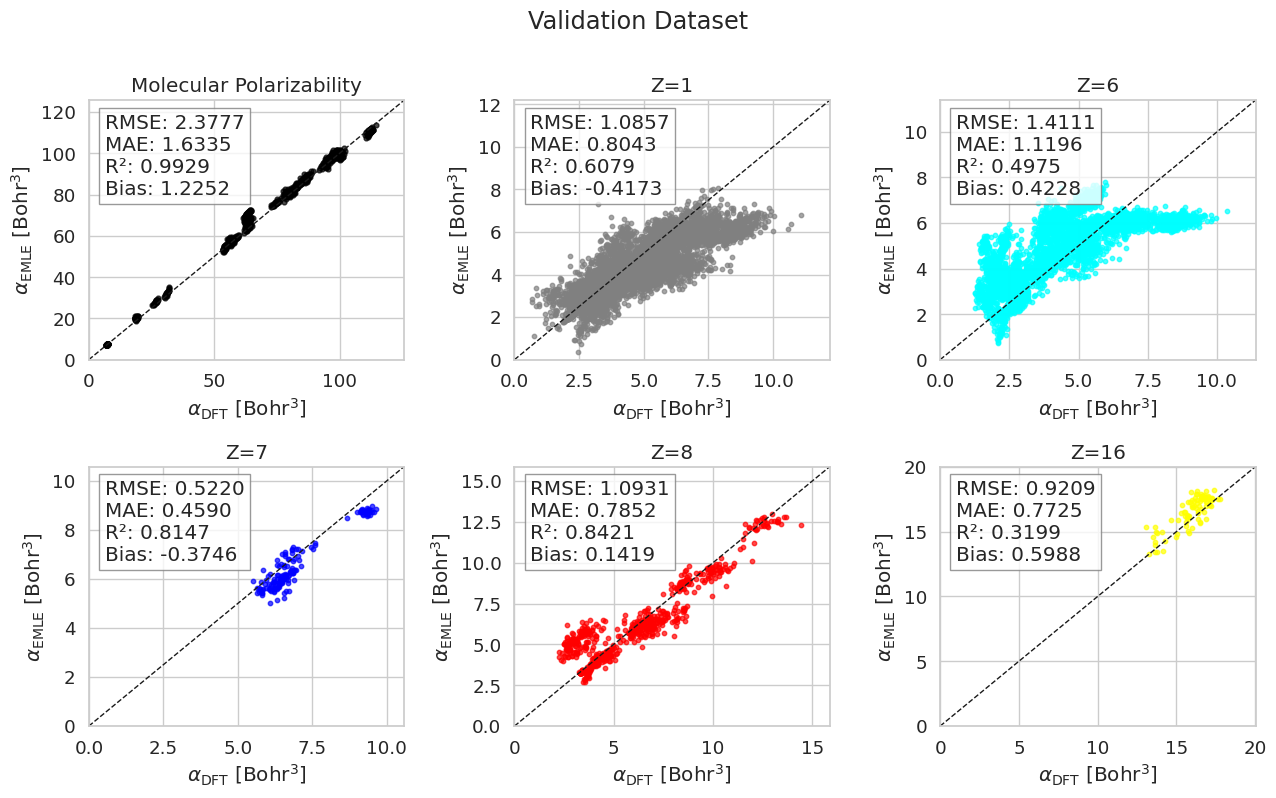

In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

datasets = [
    {
        "y_true": training_results["alpha_atomic_qm"],
        "y_pred": training_results["alpha_atomic_reference_emle"],
        "y_mol_true": np.trace(training_results["alpha_qm"], axis1=1, axis2=2) / 3.0,
        "y_mol_pred": np.trace(training_results["alpha_reference"], axis1=1, axis2=2)
        / 3.0,
        "species": species_train.cpu().numpy(),
        "title": "Training Dataset",
    },
    {
        "y_true": atomic_alpha_val.cpu().numpy(),
        "y_pred": alpha_emle_val.cpu().numpy(),
        "y_mol_true": (mol_alpha_val.diagonal(dim1=1, dim2=2).sum(-1) / 3.0)
        .cpu()
        .numpy(),
        "y_mol_pred": alpha_emle_val.sum(dim=1).cpu().numpy(),
        "species": species_val.cpu().numpy(),
        "title": "Validation Dataset",
    },
]

xlabel = r"$\alpha_{\mathrm{DFT}}$ [Bohr$^3$]"
ylabel = r"$\alpha_{\mathrm{EMLE}}$ [Bohr$^3$]"

for data in datasets:
    y_true_atomic = data["y_true"]
    y_pred_atomic = data["y_pred"]
    mol_true = data["y_mol_true"]
    mol_pred = data["y_mol_pred"]
    species = data["species"]
    title = data["title"]

    Z_values = sorted(color_by_z.keys())
    n_panels = 6
    n_Z = len(Z_values)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()

    ax = axes[0]

    mask = mol_true > 0
    rmse = np.sqrt(mean_squared_error(mol_true[mask], mol_pred[mask]))
    mae = mean_absolute_error(mol_true[mask], mol_pred[mask])
    r2 = r2_score(mol_true[mask], mol_pred[mask])
    bias = np.mean(mol_pred[mask] - mol_true[mask])

    ax.scatter(mol_true[mask], mol_pred[mask], color="black", s=12, alpha=0.7)
    lim = max(mol_true.max(), mol_pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1)
    ax.set_xlim([0, lim])
    ax.set_ylim([0, lim])

    plt.suptitle(f"{title}", y=1.00)
    ax.set_title("Molecular Polarizability")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(
        0.05,
        0.95,
        f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nBias: {bias:.4f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )
    for i, Z in enumerate(Z_values, start=1):
        if i >= n_panels:
            break

        ax = axes[i]

        mask = (species == Z) & (y_true_atomic > 0)
        x = y_true_atomic[mask]
        y = y_pred_atomic[mask]

        if len(x) == 0:
            ax.set_title(f"Z={Z} (no atoms)")
            ax.axis("off")
            continue

        rmse = np.sqrt(mean_squared_error(x, y))
        mae = mean_absolute_error(x, y)
        r2 = r2_score(x, y)
        bias = np.mean(y - x)

        ax.scatter(x, y, color=color_by_z[Z], alpha=0.7, s=10)

        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "k--", linewidth=1)
        ax.set_xlim([0, lim])
        ax.set_ylim([0, lim])

        ax.set_title(f"Z={Z}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        ax.text(
            0.05,
            0.95,
            f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nBias: {bias:.4f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
        )

    for j in range(1 + n_Z, n_panels):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()